In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

2026-03-01 22:29:48.156887: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-01 22:29:48.890901: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-01 22:29:51.162203: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
IMG_SIZE=224
BATCH_SIZE=32
EPOCHS=20
N_TRAIN=4000
N_TEST=800
NUM_CLASSES=20
CANVAS_SIZE = 96
MAX_OBJECTS = 5

VOC_LABELS=['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable',
             'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

ds_train_full, ds_validation=tfds.load('voc/2007', split=['train+validation', 'test'], shuffle_files=True, as_supervised=False)

2026-03-01 22:29:53.425853: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
# Filter out samples without objects
def has_object(sample):
    n=tf.shape(sample['objects']['bbox'])[0]
    return n>0

In [4]:
def preprocess_data(sample):
    image = sample['image']
    bboxes = sample['objects']['bbox']
    labels = sample['objects']['label']

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0

    # Convert to xyxy
    ymin = bboxes[:, 0]
    xmin = bboxes[:, 1]
    ymax = bboxes[:, 2]
    xmax = bboxes[:, 3]
    bboxes = tf.stack([xmin, ymin, xmax, ymax], axis=1)

    num_objects = tf.shape(bboxes)[0]

    # pad or truncate
    bboxes = bboxes[:MAX_OBJECTS]
    labels = labels[:MAX_OBJECTS]

    padding = MAX_OBJECTS - tf.shape(bboxes)[0]

    bboxes = tf.pad(bboxes, [[0, padding], [0, 0]])
    labels = tf.pad(labels, [[0, padding]])

    return image, {
        "class_output": labels,
        "bbox_output": bboxes
    }

In [5]:
ds_train_full=ds_train_full.filter(has_object)
ds_train_full=ds_train_full.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).shuffle(1000).prefetch(tf.data.AUTOTUNE)
ds_validation=ds_validation.filter(has_object)
ds_validation=ds_validation.map(preprocess_data, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [6]:
ds_train=ds_train_full.map(lambda img, t: (img,{"class_output": t["class_output"], "bbox_output": t["bbox_output"]}) ).prefetch(tf.data.AUTOTUNE)

In [7]:
backbone = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), weights="imagenet", include_top=False)

In [8]:
backbone.trainable = False

In [9]:
inputs=tf.keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))

x=backbone(inputs)
x=tf.keras.layers.GlobalAveragePooling2D()(x)
x=tf.keras.layers.Dense(128,activation='relu')(x)

class_output = tf.keras.layers.Dense(MAX_OBJECTS * NUM_CLASSES)(x)
class_output = tf.keras.layers.Reshape((MAX_OBJECTS, NUM_CLASSES))(class_output)
class_output = tf.keras.layers.Softmax(axis=-1, name="class_output")(class_output)

bbox_output = tf.keras.layers.Dense(MAX_OBJECTS * 4, activation="sigmoid")(x)
bbox_output = tf.keras.layers.Reshape((MAX_OBJECTS, 4), name="bbox_output")(bbox_output)

model=tf.keras.Model(inputs=inputs,outputs=[class_output,bbox_output])

In [10]:
def iou_metric(y_true, y_pred):
    x_1_true=y_true[:,0]
    y_1_true=y_true[:,1]
    x_2_true=y_true[:,2]
    y_2_true=y_true[:,3]

    x_1_pred=y_pred[:,0]
    y_1_pred=y_pred[:,1]
    x_2_pred=y_pred[:,2]
    y_2_pred=y_pred[:,3]

    x_1_inter=tf.maximum(x_1_true, x_1_pred)
    y_1_inter=tf.maximum(y_1_true, y_1_pred)
    x_2_inter=tf.minimum(x_2_true, x_2_pred)
    y_2_inter=tf.minimum(y_2_true, y_2_pred)

    inter_area=tf.maximum(0.0, x_2_inter-x_1_inter)*tf.maximum(0.0, y_2_inter-y_1_inter)
    true_area=(x_2_true-x_1_true)*(y_2_true-y_1_true)
    pred_area=(x_2_pred-x_1_pred)*(y_2_pred-y_1_pred)
    union_area=true_area+pred_area-inter_area
    iou=inter_area/(union_area+1e-6)
    return tf.reduce_mean(iou)

In [ ]:
model.compile(
    optimizer='adam',
    loss={
        "class_output": "sparse_categorical_crossentropy",
        "bbox_output": "mse"
    },
    metrics={
        "class_output": "accuracy",
        "bbox_output": "mae"
    }
)

: 

In [ ]:
history=model.fit(ds_train,validation_data=ds_validation,epochs=EPOCHS)

Epoch 1/20


2026-03-01 22:29:57.790714: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


    157/Unknown 72s 428ms/step - bbox_output_loss: 0.1073 - bbox_output_mae: 0.2482 - class_output_accuracy: 0.5827 - class_output_loss: 1.6278 - loss: 1.7357

2026-03-01 22:31:06.849328: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/ehab/.local/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


157/157 ━━━━━━━━━━━━━━━━━━━━ 139s 855ms/step - bbox_output_loss: 0.0870 - bbox_output_mae: 0.2136 - class_output_accuracy: 0.6514 - class_output_loss: 1.2984 - loss: 1.3950 - val_bbox_output_loss: 0.0704 - val_bbox_output_mae: 0.1872 - val_class_output_accuracy: 0.7126 - val_class_output_loss: 0.9675 - val_loss: 1.0452
Epoch 2/20


2026-03-01 22:32:13.414773: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


157/157 ━━━━━━━━━━━━━━━━━━━━ 130s 818ms/step - bbox_output_loss: 0.0665 - bbox_output_mae: 0.1795 - class_output_accuracy: 0.7234 - class_output_loss: 0.8828 - loss: 0.9564 - val_bbox_output_loss: 0.0634 - val_bbox_output_mae: 0.1734 - val_class_output_accuracy: 0.7251 - val_class_output_loss: 0.8788 - val_loss: 0.9489
Epoch 3/20


2026-03-01 22:34:23.264947: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - bbox_output_loss: 0.0621 - bbox_output_mae: 0.1714 - class_output_accuracy: 0.7543 - class_output_loss: 0.7491 - loss: 0.8117

In [ ]:
import matplotlib.patches as patches

def visualize_predictions(model, dataset, num_images=6, threshold=0.3):
    # Grab one batch
    for images, targets in dataset.take(1):
        sample_images = images[:num_images]
        true_labels = targets["class_output"][:num_images]
        true_bboxes = targets["bbox_output"][:num_images]
        break

    # Run inference
    pred_classes, pred_bboxes = model.predict(sample_images)

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i in range(num_images):
        ax = axes[i]
        img = sample_images[i].numpy()
        ax.imshow(img)

        H, W = img.shape[:2]

        # --- Ground Truth (green) ---
        for obj_idx in range(MAX_OBJECTS):
            label_idx = int(true_labels[i][obj_idx].numpy())
            bbox = true_bboxes[i][obj_idx].numpy()

            # Skip padded objects (label 0 and zero bbox)
            if np.sum(bbox) == 0:
                continue

            xmin, ymin, xmax, ymax = bbox
            rect = patches.Rectangle(
                (xmin * W, ymin * H),
                (xmax - xmin) * W,
                (ymax - ymin) * H,
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(
                xmin * W, ymin * H - 5,
                f"GT: {VOC_LABELS[label_idx]}",
                color='lime', fontsize=7,
                bbox=dict(facecolor='black', alpha=0.4, pad=1)
            )

        # --- Predictions (red) ---
        for obj_idx in range(MAX_OBJECTS):
            class_probs = pred_classes[i][obj_idx]        # shape (NUM_CLASSES,)
            confidence = np.max(class_probs)
            pred_label = np.argmax(class_probs)
            bbox = pred_bboxes[i][obj_idx]

            # Filter low-confidence predictions
            if confidence < threshold:
                continue

            xmin, ymin, xmax, ymax = np.clip(bbox, 0, 1)
            rect = patches.Rectangle(
                (xmin * W, ymin * H),
                (xmax - xmin) * W,
                (ymax - ymin) * H,
                linewidth=2, edgecolor='red', facecolor='none', linestyle='--'
            )
            ax.add_patch(rect)
            ax.text(
                xmin * W, ymax * H + 8,
                f"Pred: {VOC_LABELS[pred_label]} ({confidence:.2f})",
                color='red', fontsize=7,
                bbox=dict(facecolor='black', alpha=0.4, pad=1)
            )

        ax.set_title(f"Image {i+1}", fontsize=10)
        ax.axis('off')

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='lime', linewidth=2, label='Ground Truth'),
        Line2D([0], [0], color='black', linewidth=2, label='Prediction'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=12)
    plt.suptitle("Predictions vs Ground Truth", fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [ ]:

def print_prediction_summary(model, dataset, num_images=3):
    for images, targets in dataset.take(1):
        sample_images = images[:num_images]
        true_labels = targets["class_output"][:num_images]
        true_bboxes = targets["bbox_output"][:num_images]
        break

    pred_classes, pred_bboxes = model.predict(sample_images)

    for i in range(num_images):
        print(f"\n{'='*50}")
        print(f"Image {i+1}")
        print(f"{'='*50}")
        print(f"  {'Slot':<6} {'GT Label':<15} {'Pred Label':<15} {'Confidence':<12} {'GT BBox':<30} {'Pred BBox'}")
        print(f"  {'-'*100}")

        for obj_idx in range(MAX_OBJECTS):
            gt_label_idx = int(true_labels[i][obj_idx].numpy())
            gt_bbox = true_bboxes[i][obj_idx].numpy()

            class_probs = pred_classes[i][obj_idx]
            confidence = np.max(class_probs)
            pred_label_idx = np.argmax(class_probs)
            pred_bbox = pred_bboxes[i][obj_idx]

            gt_label_str = VOC_LABELS[gt_label_idx] if np.sum(gt_bbox) > 0 else "(empty)"
            pred_label_str = VOC_LABELS[pred_label_idx]

            print(f"  {obj_idx:<6} {gt_label_str:<15} {pred_label_str:<15} {confidence:<12.3f} "
                  f"{np.round(gt_bbox, 3)!s:<30} {np.round(pred_bbox, 3)}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


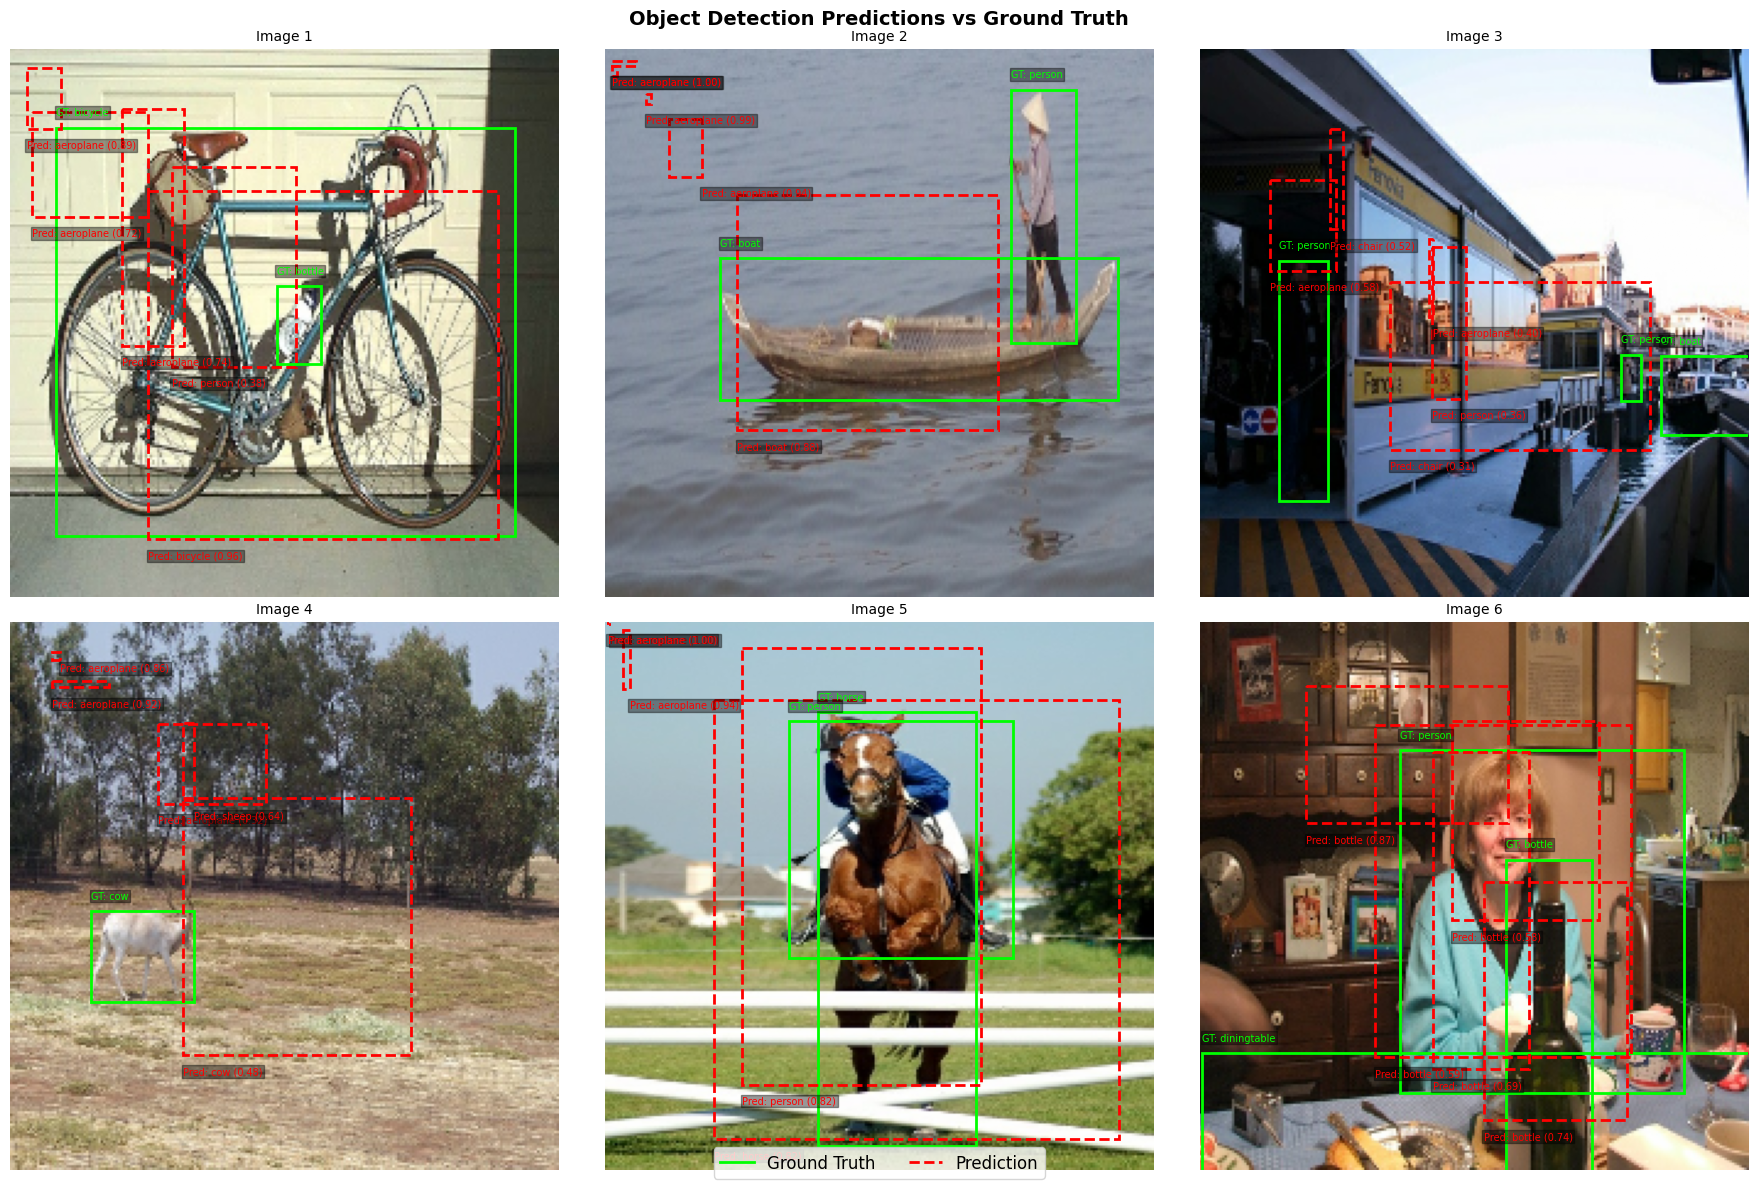

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step

Image 1
  Slot   GT Label        Pred Label      Confidence   GT BBox                        Pred BBox
  ----------------------------------------------------------------------------------------------------
  0      dog             dog             0.804        [0.142 0.372 0.624 1.   ]      [0.09  0.12  0.922 0.905]
  1      pottedplant     aeroplane       0.693        [0.508 0.207 0.724 0.583]      [0.057 0.049 0.443 0.213]
  2      (empty)         aeroplane       0.992        [0. 0. 0. 0.]                  [0.029 0.007 0.047 0.026]
  3      (empty)         aeroplane       0.999        [0. 0. 0. 0.]                  [0.001 0.003 0.006 0.003]
  4      (empty)         aeroplane       1.000        [0. 0. 0. 0.]                  [0.002 0.001 0.002 0.001]

Image 2
  Slot   GT Label        Pred Label      Confidence   GT BBox                        Pred BBox
  ----------------------------------------------------------------------------------------------

In [ ]:

visualize_predictions(model, ds_validation, num_images=6, threshold=0.3)
print_prediction_summary(model, ds_validation, num_images=3)

In [ ]:
def evaluate_bbox_iou(model, dataset, iou_threshold=0.5, num_batches=10):
    """
    Computes mean IoU and 'accuracy' (% of predictions with IoU > threshold).
    """
    all_ious = []

    for i, (images, targets) in enumerate(dataset.take(num_batches)):
        true_bboxes = targets["bbox_output"].numpy()   # (batch, MAX_OBJECTS, 4)
        true_labels = targets["class_output"].numpy()  # (batch, MAX_OBJECTS)

        pred_classes, pred_bboxes = model.predict(images, verbose=0)

        for b in range(len(images)):
            for obj_idx in range(MAX_OBJECTS):
                gt_bbox = true_bboxes[b][obj_idx]

                # Skip padded/empty ground truth slots
                if np.sum(gt_bbox) == 0:
                    continue

                pred_bbox = pred_bboxes[b][obj_idx]

                # Compute IoU
                x1 = max(gt_bbox[0], pred_bbox[0])
                y1 = max(gt_bbox[1], pred_bbox[1])
                x2 = min(gt_bbox[2], pred_bbox[2])
                y2 = min(gt_bbox[3], pred_bbox[3])

                inter = max(0, x2 - x1) * max(0, y2 - y1)
                gt_area   = (gt_bbox[2]   - gt_bbox[0])   * (gt_bbox[3]   - gt_bbox[1])
                pred_area = (pred_bbox[2] - pred_bbox[0]) * (pred_bbox[3] - pred_bbox[1])
                union = gt_area + pred_area - inter

                iou = inter / (union + 1e-6)
                all_ious.append(iou)

    all_ious = np.array(all_ious)

    mean_iou  = np.mean(all_ious)
    bbox_acc  = np.mean(all_ious >= iou_threshold) * 100   # % of boxes with IoU > threshold

    print(f"{'='*45}")
    print(f"  BBox Evaluation over {len(all_ious)} objects")
    print(f"{'='*45}")
    print(f"  Mean IoU:                  {mean_iou:.4f}")
    print(f"  BBox Accuracy (IoU≥{iou_threshold}):   {bbox_acc:.2f}%")
    print(f"  IoU distribution:")
    for threshold in [0.25, 0.50, 0.75]:
        pct = np.mean(all_ious >= threshold) * 100
        print(f"    IoU ≥ {threshold}: {pct:.2f}%")
    print(f"{'='*45}")

    return mean_iou, bbox_acc


mean_iou, bbox_acc = evaluate_bbox_iou(model, ds_validation, iou_threshold=0.5)

  BBox Evaluation over 808 objects
  Mean IoU:                  0.1650
  BBox Accuracy (IoU≥0.5):   11.26%
  IoU distribution:
    IoU ≥ 0.25: 28.09%
    IoU ≥ 0.5: 11.26%
    IoU ≥ 0.75: 1.36%
